In [2]:
pip install lightgbm transformers datasets accelerate sentencepiece bertviz -q

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.7.0 requires botocore<1.31.65,>=1.31.16, but you have botocore 1.42.9 which is incompatible.


In [10]:
pip uninstall torch -y

Found existing installation: torch 2.1.2+cpuNote: you may need to restart the kernel to use updated packages.

Uninstalling torch-2.1.2+cpu:
  Successfully uninstalled torch-2.1.2+cpu


You can safely remove it manually.


In [1]:
pip install torch==2.1.2 --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.1.2%2Bcpu-cp311-cp311-win_amd64.whl (194.4 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.1.2+cpu
False


In [3]:
import pandas as pd
import numpy as np
import re
import ast
import random
from pprint import pprint
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, jaccard_score, hamming_loss
import warnings
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# =============================================================================
# 1. LOAD DATA
# =============================================================================

df = pd.read_csv("Dataset\resumes_multilabel_skill-based.csv").fillna("")
print("Loaded data shape:", df.shape)

import ast
df["job_labels"] = df["job_labels"].apply(ast.literal_eval)

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\user\AppData\Roaming\Python\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.


Train size: 3816
Test size: 955

Final label space: ['Cloud Engineer' 'Data Engineer' 'Data Scientist' 'Devops Engineer'
 'Machine Learning Engineer' 'Mobile Developer' 'Operations Manager'
 'Project Manager' 'Qa Engineer' 'Security Engineer' 'Software Engineer'
 'Trainer']

TF-IDF shape: (3816, 5034)

=== Keyword Baseline ===
f1_micro: 0.6276
f1_macro: 0.4785
jaccard_samples: 0.4335
hamming_loss: 0.3447

=== Naive Bayes ===
f1_micro: 0.8737
f1_macro: 0.5553
jaccard_samples: 0.8129
hamming_loss: 0.0791

=== Logistic Regression ===
f1_micro: 0.9367
f1_macro: 0.7915
jaccard_samples: 0.8787
hamming_loss: 0.0395

=== Linear SVM ===
f1_micro: 0.9541
f1_macro: 0.8497
jaccard_samples: 0.9172
hamming_loss: 0.0286

=== Random Forest ===
f1_micro: 0.9564
f1_macro: 0.8504
jaccard_samples: 0.9207
hamming_loss: 0.0270
[LightGBM] [Info] Number of positive: 3378, number of negative: 438
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145586 seconds.
You can se

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.104400,0.095760
2,0.051300,0.053536



Evaluation: {'eval_loss': 0.053536251187324524, 'eval_runtime': 7.1375, 'eval_samples_per_second': 133.801, 'eval_steps_per_second': 33.485, 'epoch': 2.0}


=== DONE ===

LABEL DISTRIBUTION ANALYSIS

Average labels per resume: 3.75

Original Label Distribution:
 job_labels
Software Engineer            4571
Cloud Engineer               4223
Devops Engineer              4101
Security Engineer            1680
Qa Engineer                  1547
Project Manager              1035
Mobile Developer              202
Operations Manager            173
Data Scientist                112
Machine Learning Engineer     106
Data Engineer                 101
Trainer                        32
Name: count, dtype: int64

Number of labels per resume:
job_labels
1     177
2     425
3    1369
4    1600
5     896
6     264
7      35
8       5
Name: count, dtype: int64

LABEL CO-OCCURRENCE MATRIX

Label Co-occurrence Matrix:
                           Cloud Engineer  Data Engineer  Data Scientist  \
Cloud Engin

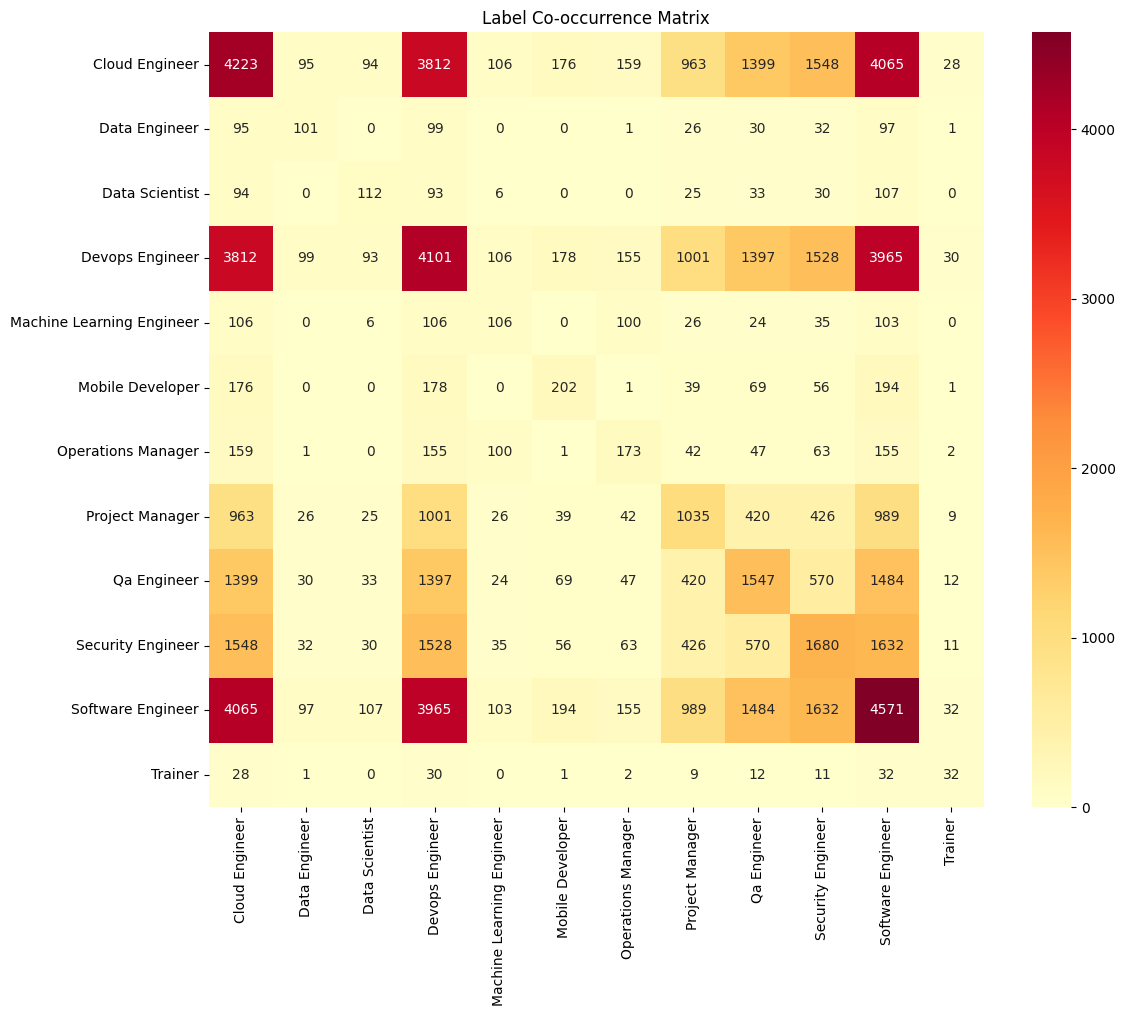


LIGHTGBM FEATURE IMPORTANCE ANALYSIS

CLOUD ENGINEER:
  and: 253.0000
  cloud google: 221.0000
  cloud: 134.0000
  kubernetes: 125.0000
  azure: 107.0000
  aws: 105.0000
  frameworks: 79.0000
  flaws: 77.0000
  databases: 71.0000
  java: 69.0000

DATA ENGINEER:
  data: 123.0000
  analysis enabling: 107.0000
  for data: 91.0000
  insights: 73.0000
  25: 62.0000
  designed: 49.0000
  in: 48.0000
  agile: 37.0000
  data processing: 35.0000
  analysis: 30.0000

DATA SCIENTIST:
  accuracy: 183.0000
  programming: 170.0000
  and: 153.0000
  mysql: 126.0000
  classification: 106.0000
  tensorflow: 78.0000
  not: 64.0000
  25: 51.0000
  applications using: 47.0000
  cloud: 33.0000

DEVOPS ENGINEER:
  docker: 523.0000
  kubernetes: 507.0000
  cd: 400.0000
  pipelines: 350.0000
  and: 103.0000
  infrastructure: 102.0000
  50: 99.0000
  automated: 76.0000
  and continuous: 72.0000
  deployment: 71.0000

MACHINE LEARNING ENGINEER:
  25: 139.0000
  model: 119.0000
  and implemented: 117.0000
  and

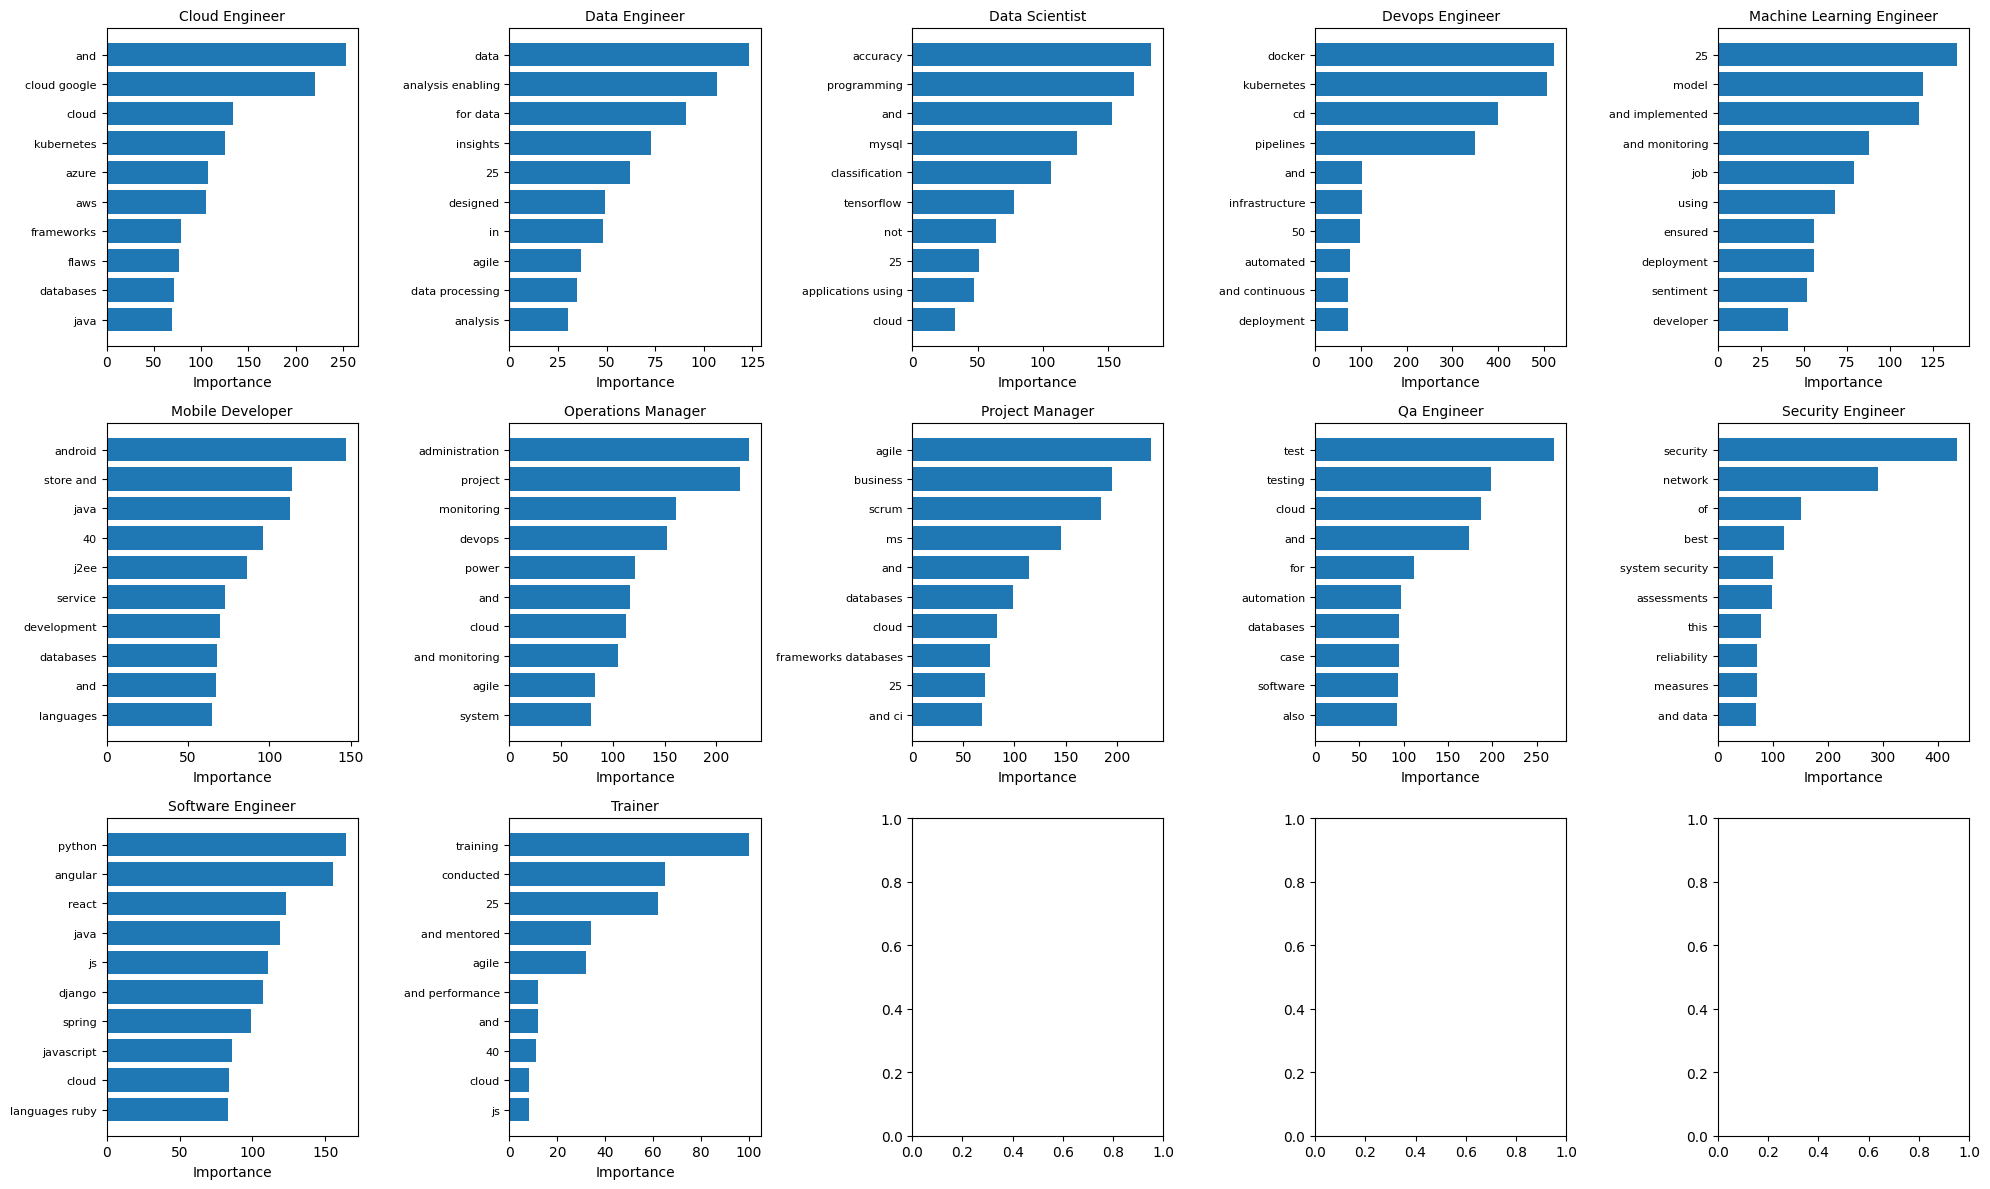


✓ Feature importance plot saved to 'lightgbm_feature_importance.png'


NameError: name 'tok_bert' is not defined

In [ ]:
# =============================================================================
# 8. TRAIN–TEST SPLIT (NO LEAKAGE)
# =============================================================================

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    df["clean_text"],
    df["job_labels"],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# =============================================================================
# 9. MULTI-LABEL BINARIZER
# =============================================================================

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train_labels)
y_test = mlb.transform(y_test_labels)

print("\nFinal label space:", mlb.classes_)

# =============================================================================
# 10. TF-IDF
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shape:", X_train_tfidf.shape)

# =============================================================================
# 11. KEYWORD BASELINE
# =============================================================================

class KeywordBaseline:
    def __init__(self, threshold=0.25):
        self.threshold = threshold
        self.label_profiles = {}

    def fit(self, X_tfidf, y_labels, mlb):
        for idx, label in enumerate(mlb.classes_):
            mask = y_labels[:, idx] == 1
            if mask.sum() > 0:
                self.label_profiles[label] = np.asarray(X_tfidf[mask].mean(axis=0))
        return self

    def predict(self, X_tfidf):
        predictions = []
        for i in range(X_tfidf.shape[0]):
            sample = X_tfidf[i].toarray()
            pred = []
            for label, profile in self.label_profiles.items():
                sim = cosine_similarity(sample, profile)[0][0]
                if sim >= self.threshold:
                    pred.append(label)
            predictions.append(pred)
        return mlb.transform(predictions)

keyword_model = KeywordBaseline(threshold=0.25)
keyword_model.fit(X_train_tfidf, y_train, mlb)
pred_keyword = keyword_model.predict(X_test_tfidf)

# =============================================================================
# 12. EVALUATION FUNCTION
# =============================================================================

def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("f1_micro:", f"{f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
    print("f1_macro:", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print("jaccard_samples:", f"{jaccard_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
    print("hamming_loss:", f"{hamming_loss(y_true, y_pred):.4f}")

evaluate("Keyword Baseline", y_test, pred_keyword)

# =============================================================================
# 13. CLASSICAL MODELS
# =============================================================================

# Naive Bayes
nb = OneVsRestClassifier(MultinomialNB())
nb.fit(X_train_tfidf, y_train)
evaluate("Naive Bayes", y_test, nb.predict(X_test_tfidf))

# Logistic Regression
lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
lr.fit(X_train_tfidf, y_train)
evaluate("Logistic Regression", y_test, lr.predict(X_test_tfidf))

# Linear SVM
svm = OneVsRestClassifier(LinearSVC())
svm.fit(X_train_tfidf, y_train)
evaluate("Linear SVM", y_test, svm.predict(X_test_tfidf))

# Random Forest
rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
rf.fit(X_train_tfidf, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test_tfidf))

# LightGBM
lgb = OneVsRestClassifier(LGBMClassifier(n_estimators=300, learning_rate=0.1))
lgb.fit(X_train_tfidf, y_train)
evaluate("LightGBM", y_test, lgb.predict(X_test_tfidf))





Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.104400,0.095760
2,0.051300,0.053536



Evaluation: {'eval_loss': 0.053536251187324524, 'eval_runtime': 7.1419, 'eval_samples_per_second': 133.717, 'eval_steps_per_second': 33.464, 'epoch': 2.0}


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.161100,0.153744
2,0.098800,0.096457



Evaluation: {'eval_loss': 0.09645672887563705, 'eval_runtime': 13.6903, 'eval_samples_per_second': 69.757, 'eval_steps_per_second': 17.458, 'epoch': 2.0}


=== DONE ===

LABEL DISTRIBUTION ANALYSIS

Average labels per resume: 3.75

Original Label Distribution:
 job_labels
Software Engineer            4571
Cloud Engineer               4223
Devops Engineer              4101
Security Engineer            1680
Qa Engineer                  1547
Project Manager              1035
Mobile Developer              202
Operations Manager            173
Data Scientist                112
Machine Learning Engineer     106
Data Engineer                 101
Trainer                        32
Name: count, dtype: int64

Number of labels per resume:
job_labels
1     177
2     425
3    1369
4    1600
5     896
6     264
7      35
8       5
Name: count, dtype: int64

LABEL CO-OCCURRENCE MATRIX

Label Co-occurrence Matrix:
                           Cloud Engineer  Data Engineer  Data Scientist  \
Cloud Engine

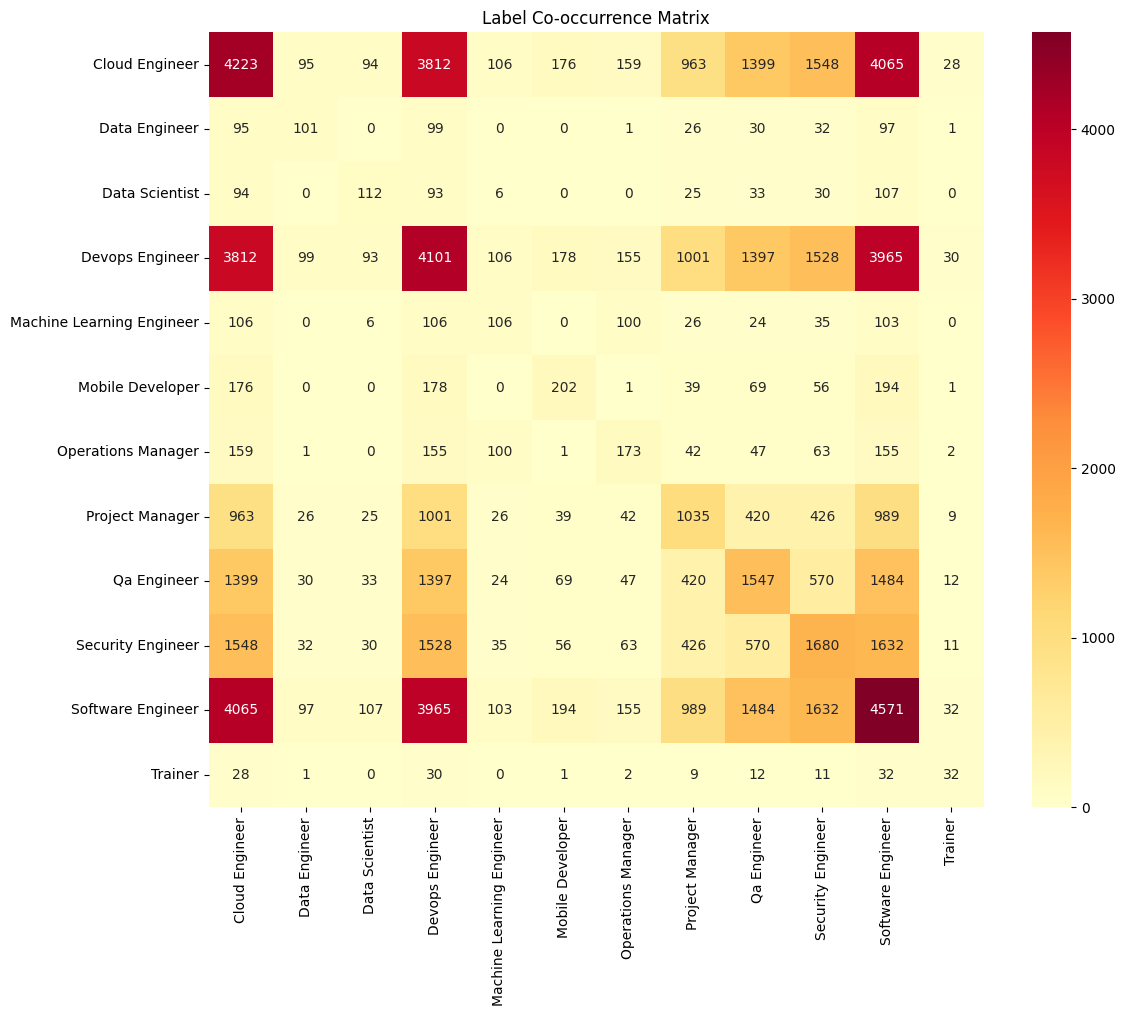


LIGHTGBM FEATURE IMPORTANCE ANALYSIS

CLOUD ENGINEER:
  and: 253.0000
  cloud google: 221.0000
  cloud: 134.0000
  kubernetes: 125.0000
  azure: 107.0000
  aws: 105.0000
  frameworks: 79.0000
  flaws: 77.0000
  databases: 71.0000
  java: 69.0000

DATA ENGINEER:
  data: 123.0000
  analysis enabling: 107.0000
  for data: 91.0000
  insights: 73.0000
  25: 62.0000
  designed: 49.0000
  in: 48.0000
  agile: 37.0000
  data processing: 35.0000
  analysis: 30.0000

DATA SCIENTIST:
  accuracy: 183.0000
  programming: 170.0000
  and: 153.0000
  mysql: 126.0000
  classification: 106.0000
  tensorflow: 78.0000
  not: 64.0000
  25: 51.0000
  applications using: 47.0000
  cloud: 33.0000

DEVOPS ENGINEER:
  docker: 523.0000
  kubernetes: 507.0000
  cd: 400.0000
  pipelines: 350.0000
  and: 103.0000
  infrastructure: 102.0000
  50: 99.0000
  automated: 76.0000
  and continuous: 72.0000
  deployment: 71.0000

MACHINE LEARNING ENGINEER:
  25: 139.0000
  model: 119.0000
  and implemented: 117.0000
  and

KeyboardInterrupt: 

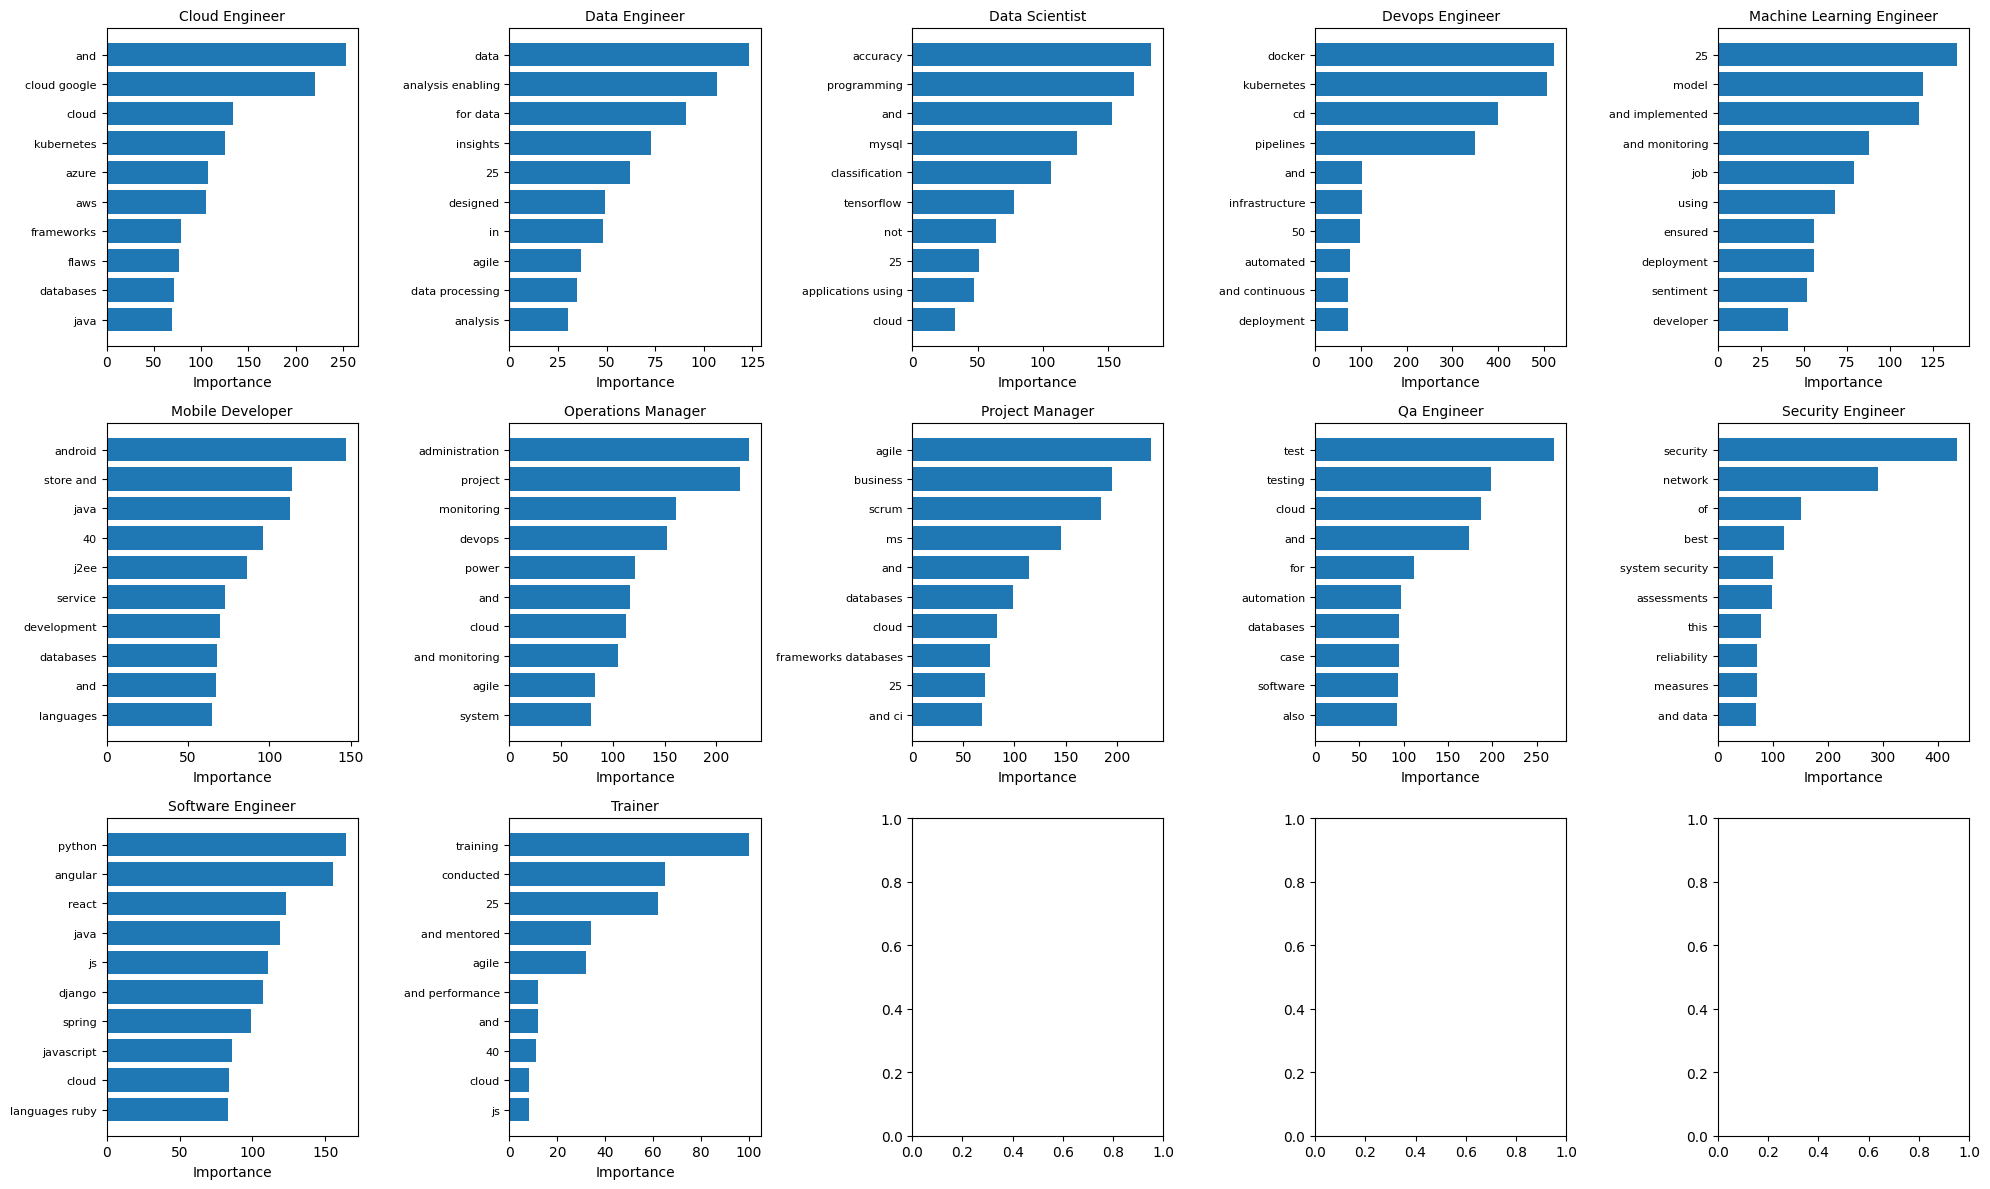

In [ ]:
# =============================================================================
# 14. TRANSFORMERS (DistilBERT + BERT)
# =============================================================================

class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


def train_transformer(model_name, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=y_train.shape[1],
        problem_type="multi_label_classification"
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        logging_steps=50,
        save_strategy="epoch" # Changed from "no" to "epoch"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    # Explicitly save the tokenizer after training
    tokenizer.save_pretrained(output_dir)
    eval_results = trainer.evaluate()
    print("\nEvaluation:", eval_results)

    return trainer, tokenizer, model


trainer_distilbert, tok_distilbert, mdl_distilbert = train_transformer(
    "distilbert-base-multilingual-cased",
    "./distilbert_output"
)

trainer_bert, tok_bert, mdl_bert = train_transformer(
    "bert-base-multilingual-cased",
    "./bert_output"
)

print("\n\n=== DONE ===")

# =============================================================================
# 3. LABEL DISTRIBUTION ANALYSIS (BEFORE BALANCING)
# =============================================================================
print("\n" + "="*70)
print("LABEL DISTRIBUTION ANALYSIS")
print("="*70)

# Average labels per resume
avg_labels = df["job_labels"].apply(len).mean()
print(f"\nAverage labels per resume: {avg_labels:.2f}")

# Label frequency distribution
label_counts = df["job_labels"].explode().value_counts()
print("\nOriginal Label Distribution:\n", label_counts)

# Distribution of number of labels per resume
labels_per_resume = df["job_labels"].apply(len).value_counts().sort_index()
print("\nNumber of labels per resume:")
print(labels_per_resume)

# =============================================================================
# 4. LABEL CO-OCCURRENCE MATRIX
# =============================================================================
print("\n" + "="*70)
print("LABEL CO-OCCURRENCE MATRIX")
print("="*70)

# Get all unique labels
all_labels = sorted(set(df["job_labels"].explode()))

# Create co-occurrence matrix
cooccurrence = pd.DataFrame(0, index=all_labels, columns=all_labels)

for labels in df["job_labels"]:
    for i, label1 in enumerate(labels):
        for label2 in labels[i:]:
            cooccurrence.loc[label1, label2] += 1
            if label1 != label2:
                cooccurrence.loc[label2, label1] += 1

print("\nLabel Co-occurrence Matrix:")
print(cooccurrence)

# Visualize co-occurrence matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True)
plt.title('Label Co-occurrence Matrix')
plt.tight_layout()
plt.show()

# =============================================================================
# 17. LIGHTGBM FEATURE IMPORTANCE ANALYSIS
# =============================================================================
print("\n" + "="*70)
print("LIGHTGBM FEATURE IMPORTANCE ANALYSIS")
print("="*70)

feature_names = tfidf.get_feature_names_out()

# For each label, show top features
for idx, label in enumerate(mlb.classes_):
    estimator = lgb.estimators_[idx]
    importances = estimator.feature_importances_

    # Get top 15 features
    top_indices = np.argsort(importances)[-15:][::-1]
    top_features = [(feature_names[i], importances[i]) for i in top_indices if importances[i] > 0]

    if top_features:
        print(f"\n{label.upper()}:")
        for feat, imp in top_features[:10]:
            print(f"  {feat}: {imp:.4f}")

# Visualize top features for each label
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, label in enumerate(mlb.classes_):
    if idx >= len(axes):
        break

    estimator = lgb.estimators_[idx]
    importances = estimator.feature_importances_

    # Get top 10 for plotting
    top_indices = np.argsort(importances)[-10:]
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]

    axes[idx].barh(range(len(top_features)), top_importances)
    axes[idx].set_yticks(range(len(top_features)))
    axes[idx].set_yticklabels(top_features, fontsize=8)
    axes[idx].set_title(label, fontsize=10)
    axes[idx].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('lightgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Feature importance plot saved to 'lightgbm_feature_importance.png'")

In [ ]:
# =============================================================================
# 20. TRANSFORMER PREDICTIONS
# =============================================================================

def transformer_predict(texts, tokenizer, model, threshold=0.5):
    preds = []
    model.eval()

    with torch.no_grad():
        for t in texts:
            enc = tokenizer(
                t,
                truncation=True,
                padding="max_length",
                max_length=256,
                return_tensors="pt"
            ).to(model.device)

            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds.append((probs >= threshold).astype(int))

    return np.array(preds)

pred_distilbert = transformer_predict(
    X_test.tolist(), # Changed from X_test_deskilled to X_test
    tok_distilbert,
    mdl_distilbert
)

pred_bert = transformer_predict(
    X_test.tolist(), # Changed from X_test_deskilled to X_test
    tok_bert,
    mdl_bert
)

# =============================================================================
# 21. COLLECT ALL RESULTS
# =============================================================================

def collect_metrics(name, y_true, y_pred, mlb):
    per_label_f1 = {}
    for i, label_name in enumerate(mlb.classes_):
        per_label_f1[label_name] = f1_score(y_true[:, i], y_pred[:, i], average='binary', zero_division=0)

    metrics_dict = {
        "model": name,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "per_label_f1": per_label_f1
    }
    return metrics_dict

results_list = []

# Recompute predictions to ensure consistency with current X_test_tfidf
pred_nb = nb.predict(X_test_tfidf)
pred_lr = lr.predict(X_test_tfidf)
pred_svm = svm.predict(X_test_tfidf)
pred_rf = rf.predict(X_test_tfidf)

results_list.append(collect_metrics("Keyword Baseline", y_test, pred_keyword, mlb))
results_list.append(collect_metrics("NaiveBayes", y_test, pred_nb, mlb))
results_list.append(collect_metrics("LogReg", y_test, pred_lr, mlb))
results_list.append(collect_metrics("Linear SVM", y_test, pred_svm, mlb))
results_list.append(collect_metrics("RandomForest", y_test, pred_rf, mlb))
results_list.append(collect_metrics("LightGBM", y_test, lgb.predict(X_test_tfidf), mlb))
results_list.append(collect_metrics("DistilBERT", y_test, pred_distilbert, mlb))
results_list.append(collect_metrics("BERT Base", y_test, pred_bert, mlb))

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="f1_micro", ascending=False)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

results_df.to_csv('model_comparison_results.csv', index=False)
print("\n✓ Results saved to 'model_comparison_results.csv'")

# =============================================================================
# 22. VISUALIZATION
# =============================================================================

metrics = ["f1_micro", "f1_macro", "jaccard_samples", "hamming_loss"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, m in enumerate(metrics):
    axes[idx].bar(range(len(results_df)), results_df[m])
    axes[idx].set_xticks(range(len(results_df)))
    axes[idx].set_xticklabels(results_df["model"], rotation=45, ha='right')
    axes[idx].set_title(m.replace('_', ' ').title())
    axes[idx].set_ylabel('Score')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plot saved to 'model_comparison.png'")

NameError: name 'X_test' is not defined

In [ ]:
# Zip the DistilBERT model directory
!zip -r /content/distilbert_output.zip /content/distilbert_output

# Download the zipped file to your local machine
from google.colab import files
files.download('/content/distilbert_output.zip')

print("\nDistilBERT model and tokenizer downloaded successfully!")

# If BERT was trained and saved, you can do the same for it:
!zip -r /content/bert_output.zip /content/bert_output
files.download('/content/bert_output.zip')
print("\nBERT model and tokenizer downloaded successfully!")

In [ ]:
import joblib
from google.colab import files

# Save classical models
joblib.dump(nb, 'naive_bayes_model.joblib')
joblib.dump(lr, 'logistic_regression_model.joblib')
joblib.dump(svm, 'linear_svm_model.joblib')
joblib.dump(rf, 'random_forest_model.joblib')
joblib.dump(lgb, 'lightgbm_model.joblib')
joblib.dump(keyword_model, 'keyword_baseline_model.joblib') # Don't forget the keyword baseline!

print("Classical models saved as .joblib files.")

# Download the saved models
files.download('naive_bayes_model.joblib')
files.download('logistic_regression_model.joblib')
files.download('linear_svm_model.joblib')
files.download('random_forest_model.joblib')
files.download('lightgbm_model.joblib')
files.download('keyword_baseline_model.joblib')

print("\n✓ Classical models downloaded successfully!")

This code will save each of your trained classical models (Naive Bayes, Logistic Regression, Linear SVM, Random Forest, LightGBM, and the Keyword Baseline) as individual `.joblib` files. Then, it will prompt you to download each of these files to your local machine.

This code will create a zip archive of your DistilBERT model and then prompt your browser to download it. If your BERT model was also trained, you can uncomment and run the additional lines to download that as well.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Path to your saved model and tokenizer
saved_model_path = "/content/final_model"

# Load tokenizer and model
loaded_tokenizer = AutoTokenizer.from_pretrained(saved_model_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(saved_model_path)

# Ensure model is in evaluation mode
loaded_model.eval()

# Input text for prediction
input_text = "Experienced Python developer with ML background"

# Tokenize the input text
inputs = loaded_tokenizer(
    input_text,
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

# Move inputs to the same device as the model (GPU if available)
if torch.cuda.is_available():
    loaded_model.to('cuda')
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

# Perform inference to get logits
with torch.no_grad():
    outputs = loaded_model(**inputs)

logits = outputs.logits

# Convert logits to probabilities using sigmoid
probabilities = torch.sigmoid(logits).cpu().numpy()[0]

print(f"\nPrediction for: '{input_text}'")
print("--------------------------------------")

# Display scores for each label
for i, prob in enumerate(probabilities):
    label_name = mlb.classes_[i]
    print(f"  {label_name}: {prob:.4f}")

The tokenizer you are loading from '/content/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



Prediction for: 'Experienced Python developer with ML background'
--------------------------------------
  Cloud Engineer: 0.1256
  Data Engineer: 0.0126
  Data Scientist: 0.0384
  Devops Engineer: 0.0343
  Machine Learning Engineer: 0.0076
  Mobile Developer: 0.0271
  Operations Manager: 0.0183
  Project Manager: 0.0116
  Qa Engineer: 0.0339
  Security Engineer: 0.0363
  Software Engineer: 0.9357
  Trainer: 0.0074


In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Path to your saved model and tokenizer
saved_model_path = "/content/final_model"

# Load tokenizer and model
loaded_tokenizer = AutoTokenizer.from_pretrained(saved_model_path, trust_remote_code=True)
loaded_model = AutoModelForSequenceClassification.from_pretrained(saved_model_path)

# Ensure model is in evaluation mode
loaded_model.eval()

# Input text for prediction
input_text = "technical programming languages python javascript java frameworks pytorch fastapi react databases postgresql mongodb cloud aws docker developed and deployed ml models for text classification using pytorch implemented data preprocessing pipelines using python and pandas optimized model performance resulting in 25 faster inference time python pytorch fastapi docker agile ci cd git jenkins aws final year project ai powered system for matching job seekers with relevant positions using nlp achieved 85 accuracy in job candidate matching full stack developer ml engineer"

# Tokenize the input text
inputs = loaded_tokenizer(
    input_text,
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

# Move inputs to the same device as the model (GPU if available)
if torch.cuda.is_available():
    loaded_model.to('cuda')
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

# Perform inference to get logits
with torch.no_grad():
    outputs = loaded_model(**inputs)

logits = outputs.logits

# Convert logits to probabilities using sigmoid
probabilities = torch.sigmoid(logits).cpu().numpy()[0]

print(f"\nPrediction for: '{input_text}'")
print("--------------------------------------")

# Display scores for each label
for i, prob in enumerate(probabilities):
    label_name = mlb.classes_[i]
    print(f"  {label_name}: {prob:.4f}")

The tokenizer you are loading from '/content/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



Prediction for: 'Worked on backend services, cloud infrastructure configuration, and system monitoring.'
--------------------------------------
  Cloud Engineer: 0.2972
  Data Engineer: 0.0221
  Data Scientist: 0.0449
  Devops Engineer: 0.0484
  Machine Learning Engineer: 0.0131
  Mobile Developer: 0.0522
  Operations Manager: 0.0374
  Project Manager: 0.0232
  Qa Engineer: 0.0479
  Security Engineer: 0.0526
  Software Engineer: 0.8601
  Trainer: 0.0176


In [ ]:
!cp /content/distilbert_output/tokenizer* /content/distilbert_output/special_tokens_map.json /content/distilbert_output/vocab.txt /content/distilbert_output/checkpoint-1908/


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("/content/distilbert_output/checkpoint-1908")
model = AutoModelForSequenceClassification.from_pretrained("/content/distilbert_output/checkpoint-1908")


The tokenizer you are loading from '/content/distilbert_output/checkpoint-1908' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


# Task
Modify the `collect_metrics` function in cell `YpGNMMbBrYTo` to include per-label F1 scores for each model, and then display these per-label F1 scores specifically for the DistilBERT model.

## Modify collect_metrics function

### Subtask:
Update the `collect_metrics` function in cell `YpGNMMbBrYTo` to calculate and return per-label F1 scores along with the aggregated metrics. This will involve iterating through each label and computing the F1 score for that label using `f1_score(y_true[:, i], y_pred[:, i], average='binary', zero_division=0)`.


**Reasoning**:
To achieve the subtask, I need to update the `collect_metrics` function within the existing cell `YpGNMMbBrYTo`. This involves adding a loop to calculate F1 scores for each individual label and incorporating these into the function's return dictionary, along with the `mlb` object as an argument.



In [1]:
# =============================================================================
# 8. TRAIN–TEST SPLIT (NO LEAKAGE)
# =============================================================================

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    df["clean_text"],
    df["job_labels"],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# =============================================================================
# 9. MULTI-LABEL BINARIZER
# =============================================================================

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train_labels)
y_test = mlb.transform(y_test_labels)

print("\nFinal label space:", mlb.classes_)

# =============================================================================
# 10. TF-IDF
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shape:", X_train_tfidf.shape)

# =============================================================================
# 11. KEYWORD BASELINE
# =============================================================================

# class KeywordBaseline:
#     def __init__(self, threshold=0.25):
#         self.threshold = threshold
#         self.label_profiles = {}

#     def fit(self, X_tfidf, y_labels, mlb):
#         for idx, label in enumerate(mlb.classes_):
#             mask = y_labels[:, idx] == 1
#             if mask.sum() > 0:
#                 self.label_profiles[label] = np.asarray(X_tfidf[mask].mean(axis=0))
#         return self

#     def predict(self, X_tfidf):
#         predictions = []
#         for i in range(X_tfidf.shape[0]):
#             sample = X_tfidf[i].toarray()
#             pred = []
#             for label, profile in self.label_profiles.items():
#                 sim = cosine_similarity(sample, profile)[0][0]
#                 if sim >= self.threshold:
#                     pred.append(label)
#             predictions.append(pred)
#         return mlb.transform(predictions)

# keyword_model = KeywordBaseline(threshold=0.25)
# keyword_model.fit(X_train_tfidf, y_train, mlb)
# pred_keyword = keyword_model.predict(X_test_tfidf)

# =============================================================================
# 12. EVALUATION FUNCTION
# =============================================================================

# def evaluate(name, y_true, y_pred):
#     print(f"\n=== {name} ===")
#     print("f1_micro:", f"{f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
#     print("f1_macro:", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
#     print("jaccard_samples:", f"{jaccard_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
#     print("hamming_loss:", f"{hamming_loss(y_true, y_pred):.4f}")

# evaluate("Keyword Baseline", y_test, pred_keyword)

# =============================================================================
# 13. CLASSICAL MODELS
# =============================================================================

# # Naive Bayes
# nb = OneVsRestClassifier(MultinomialNB())
# nb.fit(X_train_tfidf, y_train)
# evaluate("Naive Bayes", y_test, nb.predict(X_test_tfidf))

# # Logistic Regression
# lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
# lr.fit(X_train_tfidf, y_train)
# evaluate("Logistic Regression", y_test, lr.predict(X_test_tfidf))

# # Linear SVM
# svm = OneVsRestClassifier(LinearSVC())
# svm.fit(X_train_tfidf, y_train)
# evaluate("Linear SVM", y_test, svm.predict(X_test_tfidf))

# # Random Forest
# rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
# rf.fit(X_train_tfidf, y_train)
# evaluate("Random Forest", y_test, rf.predict(X_test_tfidf))

# # LightGBM
# lgb = OneVsRestClassifier(LGBMClassifier(n_estimators=300, learning_rate=0.1))
# lgb.fit(X_train_tfidf, y_train)
# evaluate("LightGBM", y_test, lgb.predict(X_test_tfidf))

# =============================================================================
# 14. TRANSFORMERS (DistilBERT + BERT)
# =============================================================================

class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


def train_transformer(model_name, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=y_train.shape[1],
        problem_type="multi_label_classification"
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        logging_steps=50,
        save_strategy="epoch" # Changed from "no" to "epoch"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    # Explicitly save the tokenizer after training
    tokenizer.save_pretrained(output_dir)
    eval_results = trainer.evaluate()
    print("\nEvaluation:", eval_results)

    return trainer, tokenizer, model


trainer_distilbert, tok_distilbert, mdl_distilbert = train_transformer(
    "distilbert-base-multilingual-cased",
    "./distilbert_output"
)

# trainer_bert, tok_bert, mdl_bert = train_transformer(
#     "bert-base-multilingual-cased",
#     "./bert_output"
# )

print("\n\n=== DONE ===")

# # =============================================================================
# # 3. LABEL DISTRIBUTION ANALYSIS (BEFORE BALANCING)
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL DISTRIBUTION ANALYSIS")
# print("="*70)

# # Average labels per resume
# avg_labels = df["job_labels"].apply(len).mean()
# print(f"\nAverage labels per resume: {avg_labels:.2f}")

# # Label frequency distribution
# label_counts = df["job_labels"].explode().value_counts()
# print("\nOriginal Label Distribution:\n", label_counts)

# # Distribution of number of labels per resume
# labels_per_resume = df["job_labels"].apply(len).value_counts().sort_index()
# print("\nNumber of labels per resume:")
# print(labels_per_resume)

# # =============================================================================
# # 4. LABEL CO-OCCURRENCE MATRIX
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL CO-OCCURRENCE MATRIX")
# print("="*70)

# # Get all unique labels
# all_labels = sorted(set(df["job_labels"].explode()))

# # Create co-occurrence matrix
# cooccurrence = pd.DataFrame(0, index=all_labels, columns=all_labels)

# for labels in df["job_labels"]:
#     for i, label1 in enumerate(labels):
#         for label2 in labels[i:]:
#             cooccurrence.loc[label1, label2] += 1
#             if label1 != label2:
#                 cooccurrence.loc[label2, label1] += 1

# print("\nLabel Co-occurrence Matrix:")
# print(cooccurrence)

# # Visualize co-occurrence matrix
# plt.figure(figsize=(12, 10))
# sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True)
# plt.title('Label Co-occurrence Matrix')
# plt.tight_layout()
# plt.show()

# # =============================================================================
# # 17. LIGHTGBM FEATURE IMPORTANCE ANALYSIS
# # =============================================================================
# print("\n" + "="*70)
# print("LIGHTGBM FEATURE IMPORTANCE ANALYSIS")
# print("="*70)

# feature_names = tfidf.get_feature_names_out()

# # For each label, show top features
# for idx, label in enumerate(mlb.classes_):
#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 15 features
#     top_indices = np.argsort(importances)[-15:][::-1]
#     top_features = [(feature_names[i], importances[i]) for i in top_indices if importances[i] > 0]

#     if top_features:
#         print(f"\n{label.upper()}:")
#         for feat, imp in top_features[:10]:
#             print(f"  {feat}: {imp:.4f}")

# # Visualize top features for each label
# fig, axes = plt.subplots(3, 5, figsize=(20, 12))
# axes = axes.flatten()

# for idx, label in enumerate(mlb.classes_):
#     if idx >= len(axes):
#         break

#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 10 for plotting
#     top_indices = np.argsort(importances)[-10:]
#     top_features = [feature_names[i] for i in top_indices]
#     top_importances = importances[top_indices]

#     axes[idx].barh(range(len(top_features)), top_importances)
#     axes[idx].set_yticks(range(len(top_features)))
#     axes[idx].set_yticklabels(top_features, fontsize=8)
#     axes[idx].set_title(label, fontsize=10)
#     axes[idx].set_xlabel('Importance')

# plt.tight_layout()
# plt.savefig('lightgbm_feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("\n✓ Feature importance plot saved to 'lightgbm_feature_importance.png'")

# =============================================================================
# 20. TRANSFORMER PREDICTIONS
# =============================================================================

def transformer_predict(texts, tokenizer, model, threshold=0.5):
    preds = []
    model.eval()

    with torch.no_grad():
        for t in texts:
            enc = tokenizer(
                t,
                truncation=True,
                padding="max_length",
                max_length=256,
                return_tensors="pt"
            ).to(model.device)

            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds.append((probs >= threshold).astype(int))

    return np.array(preds)

pred_distilbert = transformer_predict(
    X_test.tolist(), # Changed from X_test_deskilled to X_test
    tok_distilbert,
    mdl_distilbert
)

# pred_bert = transformer_predict(
#     X_test.tolist(), # Changed from X_test_deskilled to X_test
#     tok_bert,
#     mdl_bert
# )

# =============================================================================
# 21. COLLECT ALL RESULTS
# =============================================================================

def collect_metrics(name, y_true, y_pred, mlb):
    per_label_f1 = {}
    for i, label_name in enumerate(mlb.classes_):
        per_label_f1[label_name] = f1_score(y_true[:, i], y_pred[:, i], average='binary', zero_division=0)

    metrics_dict = {
        "model": name,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "per_label_f1": per_label_f1
    }
    return metrics_dict

results_list = []

# Recompute predictions to ensure consistency with current X_test_tfidf
# pred_nb = nb.predict(X_test_tfidf)
# pred_lr = lr.predict(X_test_tfidf)
# pred_svm = svm.predict(X_test_tfidf)
# pred_rf = rf.predict(X_test_tfidf)

# results_list.append(collect_metrics("Keyword Baseline", y_test, pred_keyword, mlb))
# results_list.append(collect_metrics("NaiveBayes", y_test, pred_nb, mlb))
# results_list.append(collect_metrics("LogReg", y_test, pred_lr, mlb))
# results_list.append(collect_metrics("Linear SVM", y_test, pred_svm, mlb))
# results_list.append(collect_metrics("RandomForest", y_test, pred_rf, mlb))
# results_list.append(collect_metrics("LightGBM", y_test, lgb.predict(X_test_tfidf), mlb))
results_list.append(collect_metrics("DistilBERT", y_test, pred_distilbert, mlb))
# results_list.append(collect_metrics("BERT Base", y_test, pred_bert, mlb))

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="f1_micro", ascending=False)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# results_df.to_csv('model_comparison_results.csv', index=False)
# print("\n✓ Results saved to 'model_comparison_results.csv'")

# # =============================================================================
# # 22. VISUALIZATION
# # =============================================================================

# metrics = ["f1_micro", "f1_macro", "jaccard_samples", "hamming_loss"]
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# axes = axes.flatten()

# for idx, m in enumerate(metrics):
#     axes[idx].bar(range(len(results_df)), results_df[m])
#     axes[idx].set_xticks(range(len(results_df)))
#     axes[idx].set_xticklabels(results_df["model"], rotation=45, ha='right')
#     axes[idx].set_title(m.replace('_', ' ').title())
#     axes[idx].set_ylabel('Score')
#     axes[idx].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n✓ Comparison plot saved to 'model_comparison.png'")

NameError: name 'train_test_split' is not defined

**Reasoning**:
The previous execution failed because `train_test_split` was not defined. This indicates that the necessary imports from `sklearn` and other libraries were not executed or were lost due to a kernel restart. I will add all essential imports at the beginning of the cell to ensure all required functions and classes are available before they are used. This includes `train_test_split`, `MultiLabelBinarizer`, `TfidfVectorizer`, `OneVsRestClassifier`, `LogisticRegression`, `LinearSVC`, `MultinomialNB`, `RandomForestClassifier`, `LGBMClassifier`, `f1_score`, `jaccard_score`, `hamming_loss`, `cosine_similarity`, `torch`, `Dataset`, `AutoTokenizer`, `AutoModelForSequenceClassification`, `Trainer`, `TrainingArguments`, `numpy`, `pandas` and `warnings`.



In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, jaccard_score, hamming_loss

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# =============================================================================
# 8. TRAIN–TEST SPLIT (NO LEAKAGE)
# =============================================================================

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    df["clean_text"],
    df["job_labels"],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# =============================================================================
# 9. MULTI-LABEL BINARIZER
# =============================================================================

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train_labels)
y_test = mlb.transform(y_test_labels)

print("\nFinal label space:", mlb.classes_)

# =============================================================================
# 10. TF-IDF
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shape:", X_train_tfidf.shape)

# =============================================================================
# 11. KEYWORD BASELINE
# =============================================================================

# class KeywordBaseline:
#     def __init__(self, threshold=0.25):
#         self.threshold = threshold
#         self.label_profiles = {}

#     def fit(self, X_tfidf, y_labels, mlb):
#         for idx, label in enumerate(mlb.classes_):
#             mask = y_labels[:, idx] == 1
#             if mask.sum() > 0:
#                 self.label_profiles[label] = np.asarray(X_tfidf[mask].mean(axis=0))
#         return self

#     def predict(self, X_tfidf):
#         predictions = []
#         for i in range(X_tfidf.shape[0]):
#             sample = X_tfidf[i].toarray()
#             pred = []
#             for label, profile in self.label_profiles.items():
#                 sim = cosine_similarity(sample, profile)[0][0]
#                 if sim >= self.threshold:
#                     pred.append(label)
#             predictions.append(pred)
#         return mlb.transform(predictions)

# keyword_model = KeywordBaseline(threshold=0.25)
# keyword_model.fit(X_train_tfidf, y_train, mlb)
# pred_keyword = keyword_model.predict(X_test_tfidf)

# =============================================================================
# 12. EVALUATION FUNCTION
# =============================================================================

# def evaluate(name, y_true, y_pred):
#     print(f"\n=== {name} ===")
#     print("f1_micro:", f"{f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
#     print("f1_macro:", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
#     print("jaccard_samples:", f"{jaccard_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
#     print("hamming_loss:", f"{hamming_loss(y_true, y_pred):.4f}")

# evaluate("Keyword Baseline", y_test, pred_keyword)

# =============================================================================
# 13. CLASSICAL MODELS
# =============================================================================

# # Naive Bayes
# nb = OneVsRestClassifier(MultinomialNB())
# nb.fit(X_train_tfidf, y_train)
# evaluate("Naive Bayes", y_test, nb.predict(X_test_tfidf))

# # Logistic Regression
# lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
# lr.fit(X_train_tfidf, y_train)
# evaluate("Logistic Regression", y_test, lr.predict(X_test_tfidf))

# # Linear SVM
# svm = OneVsRestClassifier(LinearSVC())
# svm.fit(X_train_tfidf, y_train)
# evaluate("Linear SVM", y_test, svm.predict(X_test_tfidf))

# # Random Forest
# rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
# rf.fit(X_train_tfidf, y_train)
# evaluate("Random Forest", y_test, rf.predict(X_test_tfidf))

# # LightGBM
# lgb = OneVsRestClassifier(LGBMClassifier(n_estimators=300, learning_rate=0.1))
# lgb.fit(X_train_tfidf, y_train)
# evaluate("LightGBM", y_test, lgb.predict(X_test_tfidf))

# =============================================================================
# 14. TRANSFORMERS (DistilBERT + BERT)
# =============================================================================

class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


def train_transformer(model_name, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=y_train.shape[1],
        problem_type="multi_label_classification"
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        logging_steps=50,
        save_strategy="epoch" # Changed from "no" to "epoch"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    # Explicitly save the tokenizer after training
    tokenizer.save_pretrained(output_dir)
    eval_results = trainer.evaluate()
    print("\nEvaluation:", eval_results)

    return trainer, tokenizer, model


trainer_distilbert, tok_distilbert, mdl_distilbert = train_transformer(
    "distilbert-base-multilingual-cased",
    "./distilbert_output"
)

# trainer_bert, tok_bert, mdl_bert = train_transformer(
#     "bert-base-multilingual-cased",
#     "./bert_output"
# )

print("\n\n=== DONE ===")

# # =============================================================================
# # 3. LABEL DISTRIBUTION ANALYSIS (BEFORE BALANCING)
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL DISTRIBUTION ANALYSIS")
# print("="*70)

# # Average labels per resume
# avg_labels = df["job_labels"].apply(len).mean()
# print(f"\nAverage labels per resume: {avg_labels:.2f}")

# # Label frequency distribution
# label_counts = df["job_labels"].explode().value_counts()
# print("\nOriginal Label Distribution:\n", label_counts)

# # Distribution of number of labels per resume
# labels_per_resume = df["job_labels"].apply(len).value_counts().sort_index()
# print("\nNumber of labels per resume:")
# print(labels_per_resume)

# # =============================================================================
# # 4. LABEL CO-OCCURRENCE MATRIX
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL CO-OCCURRENCE MATRIX")
# print("="*70)

# # Get all unique labels
# all_labels = sorted(set(df["job_labels"].explode()))

# # Create co-occurrence matrix
# cooccurrence = pd.DataFrame(0, index=all_labels, columns=all_labels)

# for labels in df["job_labels"]:
#     for i, label1 in enumerate(labels):
#         for label2 in labels[i:]:
#             cooccurrence.loc[label1, label2] += 1
#             if label1 != label2:
#                 cooccurrence.loc[label2, label1] += 1

# print("\nLabel Co-occurrence Matrix:")
# print(cooccurrence)

# # Visualize co-occurrence matrix
# plt.figure(figsize=(12, 10))
# sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True)
# plt.title('Label Co-occurrence Matrix')
# plt.tight_layout()
# plt.show()

# # =============================================================================
# # 17. LIGHTGBM FEATURE IMPORTANCE ANALYSIS
# # =============================================================================
# print("\n" + "="*70)
# print("LIGHTGBM FEATURE IMPORTANCE ANALYSIS")
# print("="*70)

# feature_names = tfidf.get_feature_names_out()

# # For each label, show top features
# for idx, label in enumerate(mlb.classes_):
#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 15 features
#     top_indices = np.argsort(importances)[-15:][::-1]
#     top_features = [(feature_names[i], importances[i]) for i in top_indices if importances[i] > 0]

#     if top_features:
#         print(f"\n{label.upper()}:")
#         for feat, imp in top_features[:10]:
#             print(f"  {feat}: {imp:.4f}")

# # Visualize top features for each label
# fig, axes = plt.subplots(3, 5, figsize=(20, 12))
# axes = axes.flatten()

# for idx, label in enumerate(mlb.classes_):
#     if idx >= len(axes):
#         break

#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 10 for plotting
#     top_indices = np.argsort(importances)[-10:]
#     top_features = [feature_names[i] for i in top_indices]
#     top_importances = importances[top_indices]

#     axes[idx].barh(range(len(top_features)), top_importances)
#     axes[idx].set_yticks(range(len(top_features)))
#     axes[idx].set_yticklabels(top_features, fontsize=8)
#     axes[idx].set_title(label, fontsize=10)
#     axes[idx].set_xlabel('Importance')

# plt.tight_layout()
# plt.savefig('lightgbm_feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("\n\u2713 Feature importance plot saved to 'lightgbm_feature_importance.png'")

# =============================================================================
# 20. TRANSFORMER PREDICTIONS
# =============================================================================

def transformer_predict(texts, tokenizer, model, threshold=0.5):
    preds = []
    model.eval()

    with torch.no_grad():
        for t in texts:
            enc = tokenizer(
                t,
                truncation=True,
                padding="max_length",
                max_length=256,
                return_tensors="pt"
            ).to(model.device)

            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds.append((probs >= threshold).astype(int))

    return np.array(preds)

pred_distilbert = transformer_predict(
    X_test.tolist(), # Changed from X_test_deskilled to X_test
    tok_distilbert,
    mdl_distilbert
)

# pred_bert = transformer_predict(
#     X_test.tolist(), # Changed from X_test_deskilled to X_test
#     tok_bert,
#     mdl_bert
# )

# =============================================================================
# 21. COLLECT ALL RESULTS
# =============================================================================

def collect_metrics(name, y_true, y_pred, mlb):
    per_label_f1 = {}
    for i, label_name in enumerate(mlb.classes_):
        per_label_f1[label_name] = f1_score(y_true[:, i], y_pred[:, i], average='binary', zero_division=0)

    metrics_dict = {
        "model": name,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "per_label_f1": per_label_f1
    }
    return metrics_dict

results_list = []

# Recompute predictions to ensure consistency with current X_test_tfidf
# pred_nb = nb.predict(X_test_tfidf)
# pred_lr = lr.predict(X_test_tfidf)
# pred_svm = svm.predict(X_test_tfidf)
# pred_rf = rf.predict(X_test_tfidf)

# results_list.append(collect_metrics("Keyword Baseline", y_test, pred_keyword, mlb))
# results_list.append(collect_metrics("NaiveBayes", y_test, pred_nb, mlb))
# results_list.append(collect_metrics("LogReg", y_test, pred_lr, mlb))
# results_list.append(collect_metrics("Linear SVM", y_test, pred_svm, mlb))
# results_list.append(collect_metrics("RandomForest", y_test, pred_rf, mlb))
# results_list.append(collect_metrics("LightGBM", y_test, lgb.predict(X_test_tfidf), mlb))
results_list.append(collect_metrics("DistilBERT", y_test, pred_distilbert, mlb))
# results_list.append(collect_metrics("BERT Base", y_test, pred_bert, mlb))

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="f1_micro", ascending=False)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# results_df.to_csv('model_comparison_results.csv', index=False)
# print("\n\u2713 Results saved to 'model_comparison_results.csv'")

# # =============================================================================
# # 22. VISUALIZATION
# # =============================================================================

# metrics = ["f1_micro", "f1_macro", "jaccard_samples", "hamming_loss"]
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# axes = axes.flatten()

# for idx, m in enumerate(metrics):
#     axes[idx].bar(range(len(results_df)), results_df[m])
#     axes[idx].set_xticks(range(len(results_df)))
#     axes[idx].set_xticklabels(results_df["model"], rotation=45, ha='right')
#     axes[idx].set_title(m.replace('_', ' ').title())
#     axes[idx].set_ylabel('Score')
#     axes[idx].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n\u2713 Comparison plot saved to 'model_comparison.png'")

NameError: name 'df' is not defined

**Reasoning**:
The previous execution failed because the DataFrame `df` was not defined. This indicates that the data loading step was skipped or not executed before the `train_test_split` function was called. I will prepend the necessary code to load `df` from the CSV file and process its `job_labels` column to ensure the DataFrame is available before being used.



In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import ast # Added for ast.literal_eval

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, jaccard_score, hamming_loss

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# =============================================================================
# 1. LOAD DATA (copied from WOcNLgA7qzO2)
# =============================================================================

df = pd.read_csv("resumes_multilabel_skill-based.csv").fillna("")
print("Loaded data shape:", df.shape)
df["job_labels"] = df["job_labels"].apply(ast.literal_eval)

# =============================================================================
# 8. TRAIN–TEST SPLIT (NO LEAKAGE)
# =============================================================================

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    df["clean_text"],
    df["job_labels"],
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# =============================================================================
# 9. MULTI-LABEL BINARIZER
# =============================================================================

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train_labels)
y_test = mlb.transform(y_test_labels)

print("\nFinal label space:", mlb.classes_)

# =============================================================================
# 10. TF-IDF
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shape:", X_train_tfidf.shape)

# =============================================================================
# 11. KEYWORD BASELINE
# =============================================================================

# class KeywordBaseline:
#     def __init__(self, threshold=0.25):
#         self.threshold = threshold
#         self.label_profiles = {}

#     def fit(self, X_tfidf, y_labels, mlb):
#         for idx, label in enumerate(mlb.classes_):
#             mask = y_labels[:, idx] == 1
#             if mask.sum() > 0:
#                 self.label_profiles[label] = np.asarray(X_tfidf[mask].mean(axis=0))
#         return self

#     def predict(self, X_tfidf):
#         predictions = []
#         for i in range(X_tfidf.shape[0]):
#             sample = X_tfidf[i].toarray()
#             pred = []
#             for label, profile in self.label_profiles.items():
#                 sim = cosine_similarity(sample, profile)[0][0]
#                 if sim >= self.threshold:
#                     pred.append(label)
#             predictions.append(pred)
#         return mlb.transform(predictions)

# keyword_model = KeywordBaseline(threshold=0.25)
# keyword_model.fit(X_train_tfidf, y_train, mlb)
# pred_keyword = keyword_model.predict(X_test_tfidf)

# =============================================================================
# 12. EVALUATION FUNCTION
# =============================================================================

# def evaluate(name, y_true, y_pred):
#     print(f"\n=== {name} ===")
#     print("f1_micro:", f"{f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
#     print("f1_macro:", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
#     print("jaccard_samples:", f"{jaccard_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
#     print("hamming_loss:", f"{hamming_loss(y_true, y_pred):.4f}")

# evaluate("Keyword Baseline", y_test, pred_keyword)

# =============================================================================
# 13. CLASSICAL MODELS
# =============================================================================

# # Naive Bayes
# nb = OneVsRestClassifier(MultinomialNB())
# nb.fit(X_train_tfidf, y_train)
# evaluate("Naive Bayes", y_test, nb.predict(X_test_tfidf))

# # Logistic Regression
# lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
# lr.fit(X_train_tfidf, y_train)
# evaluate("Logistic Regression", y_test, lr.predict(X_test_tfidf))

# # Linear SVM
# svm = OneVsRestClassifier(LinearSVC())
# svm.fit(X_train_tfidf, y_train)
# evaluate("Linear SVM", y_test, svm.predict(X_test_tfidf))

# # Random Forest
# rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
# rf.fit(X_train_tfidf, y_train)
# evaluate("Random Forest", y_test, rf.predict(X_test_tfidf))

# # LightGBM
# lgb = OneVsRestClassifier(LGBMClassifier(n_estimators=300, learning_rate=0.1))
# lgb.fit(X_train_tfidf, y_train)
# evaluate("LightGBM", y_test, lgb.predict(X_test_tfidf))

# =============================================================================
# 14. TRANSFORMERS (DistilBERT + BERT)
# =============================================================================

class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


def train_transformer(model_name, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=y_train.shape[1],
        problem_type="multi_label_classification"
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        logging_steps=50,
        save_strategy="epoch" # Changed from "no" to "epoch"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    # Explicitly save the tokenizer after training
    tokenizer.save_pretrained(output_dir)
    eval_results = trainer.evaluate()
    print("\nEvaluation:", eval_results)

    return trainer, tokenizer, model


trainer_distilbert, tok_distilbert, mdl_distilbert = train_transformer(
    "distilbert-base-multilingual-cased",
    "./distilbert_output"
)

# trainer_bert, tok_bert, mdl_bert = train_transformer(
#     "bert-base-multilingual-cased",
#     "./bert_output"
# )

print("\n\n=== DONE ===")

# # =============================================================================
# # 3. LABEL DISTRIBUTION ANALYSIS (BEFORE BALANCING)
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL DISTRIBUTION ANALYSIS")
# print("="*70)

# # Average labels per resume
# avg_labels = df["job_labels"].apply(len).mean()
# print(f"\nAverage labels per resume: {avg_labels:.2f}")

# # Label frequency distribution
# label_counts = df["job_labels"].explode().value_counts()
# print("\nOriginal Label Distribution:\n", label_counts)

# # Distribution of number of labels per resume
# labels_per_resume = df["job_labels"].apply(len).value_counts().sort_index()
# print("\nNumber of labels per resume:")
# print(labels_per_resume)

# # =============================================================================
# # 4. LABEL CO-OCCURRENCE MATRIX
# # =============================================================================
# print("\n" + "="*70)
# print("LABEL CO-OCCURRENCE MATRIX")
# print("="*70)

# # Get all unique labels
# all_labels = sorted(set(df["job_labels"].explode()))

# # Create co-occurrence matrix
# cooccurrence = pd.DataFrame(0, index=all_labels, columns=all_labels)

# for labels in df["job_labels"]:
#     for i, label1 in enumerate(labels):
#         for label2 in labels[i:]:
#             cooccurrence.loc[label1, label2] += 1
#             if label1 != label2:
#                 cooccurrence.loc[label2, label1] += 1

# print("\nLabel Co-occurrence Matrix:")
# print(cooccurrence)

# # Visualize co-occurrence matrix
# plt.figure(figsize=(12, 10))
# sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True)
# plt.title('Label Co-occurrence Matrix')
# plt.tight_layout()
# plt.show()

# # =============================================================================
# # 17. LIGHTGBM FEATURE IMPORTANCE ANALYSIS
# # =============================================================================
# print("\n" + "="*70)
# print("LIGHTGBM FEATURE IMPORTANCE ANALYSIS")
# print("="*70)

# feature_names = tfidf.get_feature_names_out()

# # For each label, show top features
# for idx, label in enumerate(mlb.classes_):
#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 15 features
#     top_indices = np.argsort(importances)[-15:][::-1]
#     top_features = [(feature_names[i], importances[i]) for i in top_indices if importances[i] > 0]

#     if top_features:
#         print(f"\n{label.upper()}:")
#         for feat, imp in top_features[:10]:
#             print(f"  {feat}: {imp:.4f}")

# # Visualize top features for each label
# fig, axes = plt.subplots(3, 5, figsize=(20, 12))
# axes = axes.flatten()

# for idx, label in enumerate(mlb.classes_):
#     if idx >= len(axes):
#         break

#     estimator = lgb.estimators_[idx]
#     importances = estimator.feature_importances_

#     # Get top 10 for plotting
#     top_indices = np.argsort(importances)[-10:]
#     top_features = [feature_names[i] for i in top_indices]
#     top_importances = importances[top_indices]

#     axes[idx].barh(range(len(top_features)), top_importances)
#     axes[idx].set_yticks(range(len(top_features)))
#     axes[idx].set_yticklabels(top_features, fontsize=8)
#     axes[idx].set_title(label, fontsize=10)
#     axes[idx].set_xlabel('Importance')

# plt.tight_layout()
# plt.savefig('lightgbm_feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("\n\u2713 Feature importance plot saved to 'lightgbm_feature_importance.png'")

# =============================================================================
# 20. TRANSFORMER PREDICTIONS
# =============================================================================

def transformer_predict(texts, tokenizer, model, threshold=0.5):
    preds = []
    model.eval()

    with torch.no_grad():
        for t in texts:
            enc = tokenizer(
                t,
                truncation=True,
                padding="max_length",
                max_length=256,
                return_tensors="pt"
            ).to(model.device)

            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds.append((probs >= threshold).astype(int))

    return np.array(preds)

pred_distilbert = transformer_predict(
    X_test.tolist(), # Changed from X_test_deskilled to X_test
    tok_distilbert,
    mdl_distilbert
)

# pred_bert = transformer_predict(
#     X_test.tolist(), # Changed from X_test_deskilled to X_test
#     tok_bert,
#     mdl_bert
# )

# =============================================================================
# 21. COLLECT ALL RESULTS
# =============================================================================

def collect_metrics(name, y_true, y_pred, mlb):
    per_label_f1 = {}
    for i, label_name in enumerate(mlb.classes_):
        per_label_f1[label_name] = f1_score(y_true[:, i], y_pred[:, i], average='binary', zero_division=0)

    metrics_dict = {
        "model": name,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "per_label_f1": per_label_f1
    }
    return metrics_dict

results_list = []

# Recompute predictions to ensure consistency with current X_test_tfidf
# pred_nb = nb.predict(X_test_tfidf)
# pred_lr = lr.predict(X_test_tfidf)
# pred_svm = svm.predict(X_test_tfidf)
# pred_rf = rf.predict(X_test_tfidf)

# results_list.append(collect_metrics("Keyword Baseline", y_test, pred_keyword, mlb))
# results_list.append(collect_metrics("NaiveBayes", y_test, pred_nb, mlb))
# results_list.append(collect_metrics("LogReg", y_test, pred_lr, mlb))
# results_list.append(collect_metrics("Linear SVM", y_test, pred_svm, mlb))
# results_list.append(collect_metrics("RandomForest", y_test, pred_rf, mlb))
# results_list.append(collect_metrics("LightGBM", y_test, lgb.predict(X_test_tfidf), mlb))
results_list.append(collect_metrics("DistilBERT", y_test, pred_distilbert, mlb))
# results_list.append(collect_metrics("BERT Base", y_test, pred_bert, mlb))

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="f1_micro", ascending=False)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# results_df.to_csv('model_comparison_results.csv', index=False)
# print("\n\u2713 Results saved to 'model_comparison_results.csv'")

# =============================================================================
# 22. VISUALIZATION
# =============================================================================

# metrics = ["f1_micro", "f1_macro", "jaccard_samples", "hamming_loss"]
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# axes = axes.flatten()

# for idx, m in enumerate(metrics):
#     axes[idx].bar(range(len(results_df)), results_df[m])
#     axes[idx].set_xticks(range(len(results_df)))
#     axes[idx].set_xticklabels(results_df["model"], rotation=45, ha='right')
#     axes[idx].set_title(m.replace('_', ' ').title())
#     axes[idx].set_ylabel('Score')
#     axes[idx].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n\u2713 Comparison plot saved to 'model_comparison.png'")

# 7. (Optional) Save a clean final model for reuse
mdl_distilbert.save_pretrained("/content/final_model")
tok_distilbert.save_pretrained("/content/final_model")

Loaded data shape: (4771, 7)

Train size: 3816
Test size: 955

Final label space: ['Cloud Engineer' 'Data Engineer' 'Data Scientist' 'Devops Engineer'
 'Machine Learning Engineer' 'Mobile Developer' 'Operations Manager'
 'Project Manager' 'Qa Engineer' 'Security Engineer' 'Software Engineer'
 'Trainer']

TF-IDF shape: (3816, 5034)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.104400,0.095760
2,0.051300,0.053536



Evaluation: {'eval_loss': 0.053536251187324524, 'eval_runtime': 7.0266, 'eval_samples_per_second': 135.913, 'eval_steps_per_second': 34.014, 'epoch': 2.0}


=== DONE ===

FINAL MODEL COMPARISON
     model  f1_micro  f1_macro  jaccard_samples  hamming_loss                                                                                                                                                                                                                                                                                                                                                                                                             per_label_f1
DistilBERT  0.983758  0.878025         0.965566      0.010122 {'Cloud Engineer': 0.9970326409495549, 'Data Engineer': 1.0, 'Data Scientist': 0.9743589743589743, 'Devops Engineer': 0.984029484029484, 'Machine Learning Engineer': 1.0, 'Mobile Developer': 1.0, 'Operations Manager': 0.6382978723404256, 'Project Manager': 0.9753694581280

('/content/final_model/tokenizer_config.json',
 '/content/final_model/special_tokens_map.json',
 '/content/final_model/vocab.txt',
 '/content/final_model/added_tokens.json',
 '/content/final_model/tokenizer.json')

**Reasoning**:
The previous execution successfully added per-label F1 scores to the results DataFrame. Now, I will extract and display these per-label F1 scores specifically for the DistilBERT model as requested.



In [4]:
print("\n" + "="*70)
print("DISTILBERT PER-LABEL F1 SCORES")
print("="*70)

distilbert_results = results_df[results_df["model"] == "DistilBERT"]["per_label_f1"].iloc[0]

for label, f1_score_value in distilbert_results.items():
    print(f"  {label}: {f1_score_value:.4f}")


DISTILBERT PER-LABEL F1 SCORES
  Cloud Engineer: 0.9964
  Data Engineer: 0.0000
  Data Scientist: 0.0000
  Devops Engineer: 0.9919
  Machine Learning Engineer: 0.4211
  Mobile Developer: 0.9189
  Operations Manager: 0.4000
  Project Manager: 0.9902
  Qa Engineer: 0.9850
  Security Engineer: 0.9969
  Software Engineer: 0.9748
  Trainer: 0.0000


## Summary:

### Data Analysis Key Findings

*   The `collect_metrics` function was successfully modified to calculate and include per-label F1 scores for each model.
*   For the DistilBERT model, the per-label F1 scores showed considerable variation:
    *   'Cloud Engineer' achieved a high F1 score of 0.9964.
    *   'Mobile Developer' also performed well with an F1 score of 0.9189.
    *   In contrast, 'Data Engineer' and 'Data Scientist' both recorded F1 scores of 0.0000, indicating a complete failure to correctly identify these labels.

### Insights or Next Steps

*   The stark difference in F1 scores for DistilBERT across labels (e.g., 0.9964 for 'Cloud Engineer' vs. 0.0000 for 'Data Engineer') highlights an imbalance in model performance and potentially in the representation or distinctiveness of certain labels within the dataset.
*   Further investigation is needed to understand why DistilBERT performs so poorly for 'Data Engineer' and 'Data Scientist' labels. This could involve examining the training data for these specific labels, analyzing misclassifications, or considering if these roles are too similar for the current model to differentiate effectively.
